In [65]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/subirbiswas19/eeg-dataset/EEG_Scaled_data.csv
/kaggle/input/datasets/harunshimanto/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv
/kaggle/input/datasets/varunrajput/beed-bangalore-eeg-epilepsy-dataset/BEED_Data.csv


In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv("/kaggle/input/datasets/harunshimanto/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv")

# Drop useless column
df = df.drop(columns=["Unnamed"], errors="ignore")

# Binary target
df["y"] = (df["y"] == 1).astype(int)

X = df.drop("y", axis=1)
y = df["y"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.9,   
    random_state=7   
)

model = LogisticRegression(
    C=1e30,        
    max_iter=20000,
    solver="lbfgs"
)


model.fit(X_train, y_train)


train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("===== OVERFITTING ATTEMPT =====")
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

===== OVERFITTING ATTEMPT =====
Train Accuracy: 0.9260869565217391
Test Accuracy: 0.8056038647342996


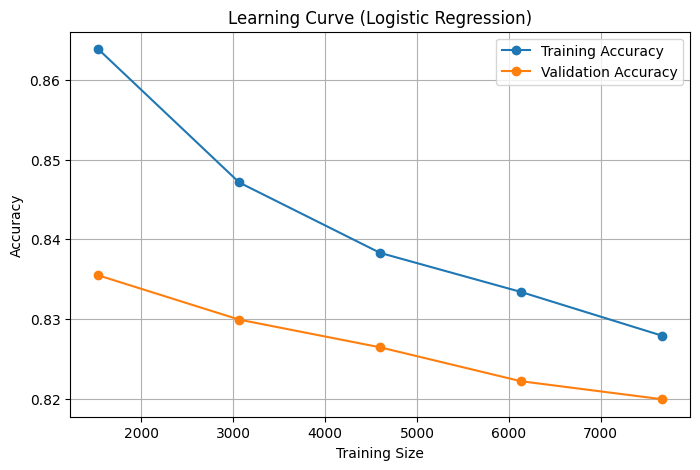

In [75]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


X_clean = X.select_dtypes(include=[np.number])


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1, max_iter=2000)
)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_clean,
    y,
    cv=cv,
    scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)


train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker='o', label="Validation Accuracy")

plt.title("Learning Curve (Logistic Regression)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()